In [1]:
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [2]:
path = 'mnist_784.arff' if os.path.exists('mnist_784.arff') else ('../mnist_784.arff' if os.path.exists('../mnist_784.arff') else 'mnist_784.arff')
data, meta = arff.loadarff(path)
df = pd.DataFrame(data)
X = df.iloc[:, :-1].values.astype(np.float32)
y = np.array([int(val.decode('utf-8') if isinstance(val, bytes) else str(val)) for val in df.iloc[:, -1]])

In [3]:
print("Number of samples:", X.shape[0])
print("Number of classes:", len(np.unique(y)))
print("Image dimensions: 28 x 28")

Number of samples: 70000
Number of classes: 10
Image dimensions: 28 x 28


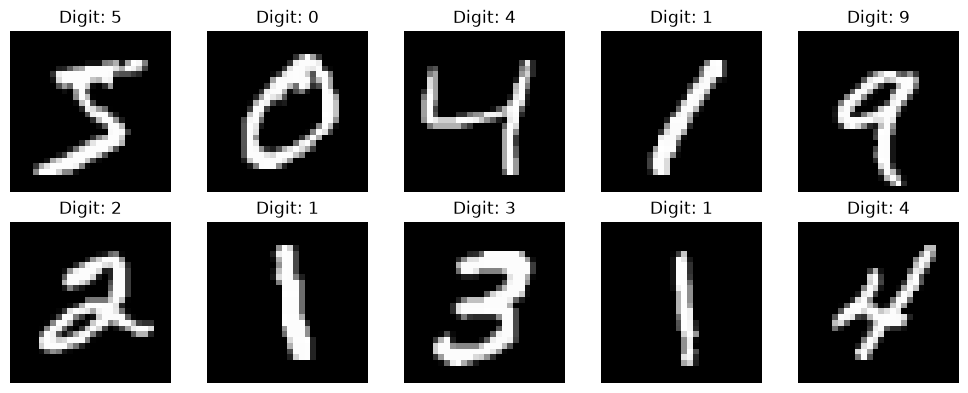

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Digit: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
X_norm = X / 255.0
print("Normalized range:", X_norm.min(), "to", X_norm.max())

Normalized range: 0.0 to 1.0


In [6]:
pca_full = PCA().fit(X_norm)
var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)
n_90 = int(np.argmax(cum_var >= 0.90) + 1)
n_95 = int(np.argmax(cum_var >= 0.95) + 1)
n_99 = int(np.argmax(cum_var >= 0.99) + 1)
print("Components for 90% variance:", n_90)
print("Components for 95% variance:", n_95)
print("Components for 99% variance:", n_99)

Components for 90% variance: 87
Components for 95% variance: 154
Components for 99% variance: 331


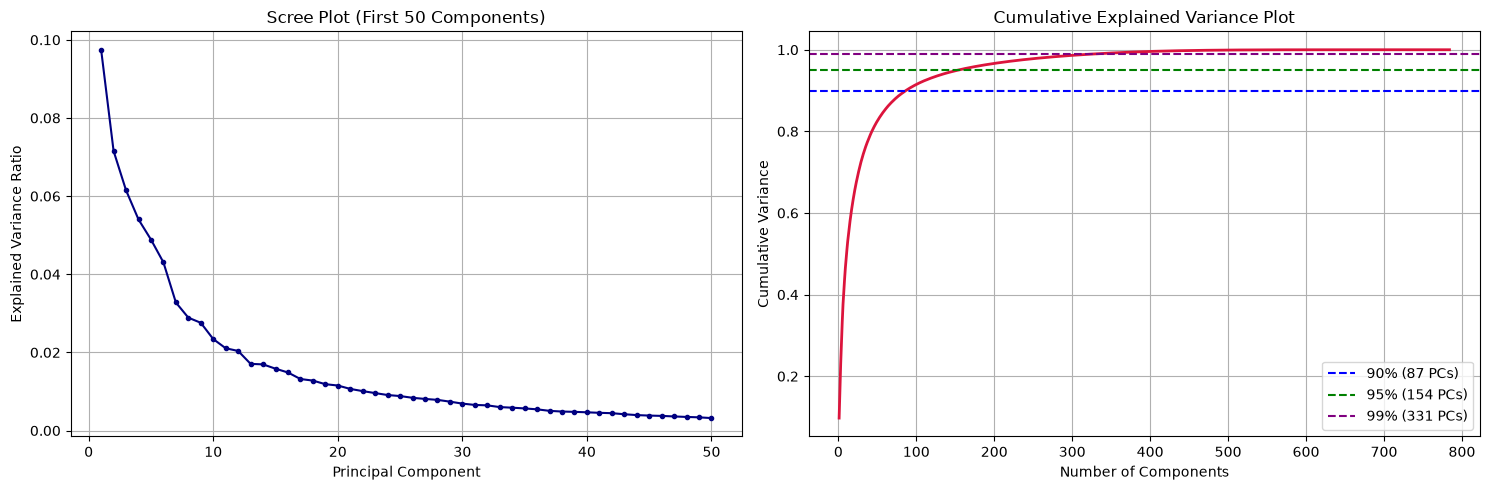

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(range(1, 51), var_ratio[:50], marker='o', markersize=3, color='navy')
ax1.set_title('Scree Plot (First 50 Components)')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.grid(True)

ax2.plot(range(1, len(cum_var) + 1), cum_var, color='crimson', lw=2)
ax2.axhline(0.90, color='blue', linestyle='--', label=f'90% ({n_90} PCs)')
ax2.axhline(0.95, color='green', linestyle='--', label=f'95% ({n_95} PCs)')
ax2.axhline(0.99, color='purple', linestyle='--', label=f'99% ({n_99} PCs)')
ax2.set_title('Cumulative Explained Variance Plot')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

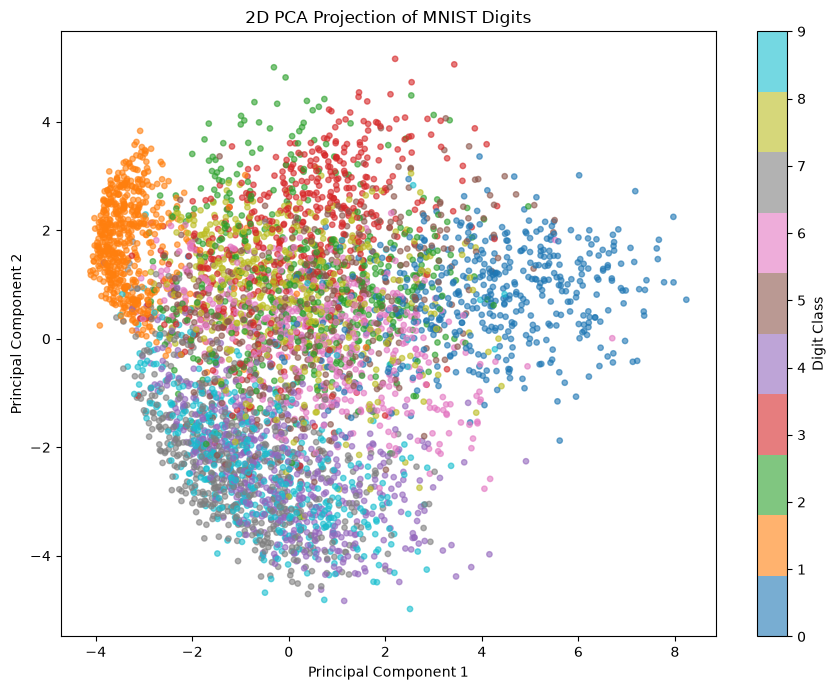

In [8]:
pca_2 = PCA(n_components=2)
X_pca_2d = pca_2.fit_transform(X_norm)

pca_50 = PCA(n_components=50)
X_pca_50d = pca_50.fit_transform(X_norm)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca_2d[:5000, 0], X_pca_2d[:5000, 1], c=y[:5000], cmap='tab10', alpha=0.6, s=15)
plt.colorbar(scatter, label='Digit Class')
plt.title('2D PCA Projection of MNIST Digits')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

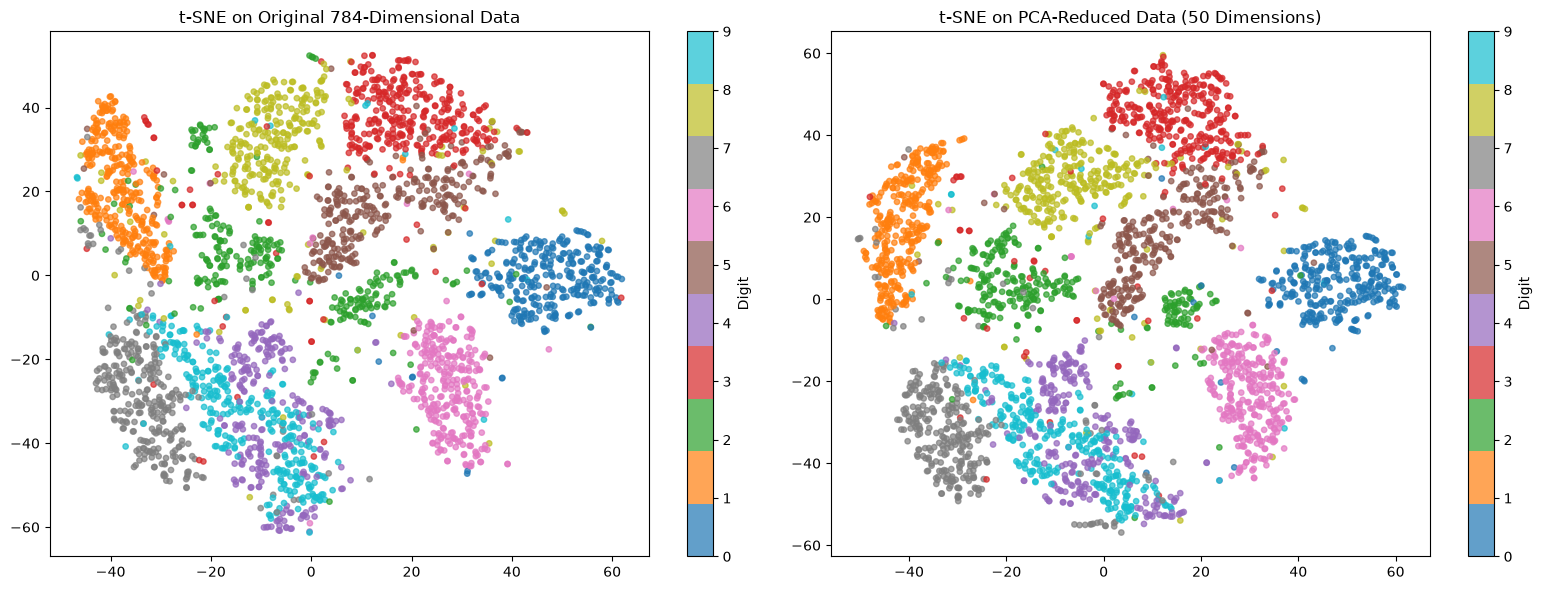

In [9]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_norm), 3000, replace=False)
X_tsne_sample = X_norm[sample_idx]
y_tsne_sample = y[sample_idx]
X_pca_tsne_sample = X_pca_50d[sample_idx]

tsne_orig = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_orig = tsne_orig.fit_transform(X_tsne_sample)

tsne_pca50 = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_pca = tsne_pca50.fit_transform(X_pca_tsne_sample)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
s1 = ax1.scatter(X_tsne_orig[:, 0], X_tsne_orig[:, 1], c=y_tsne_sample, cmap='tab10', alpha=0.7, s=15)
ax1.set_title('t-SNE on Original 784-Dimensional Data')
plt.colorbar(s1, ax=ax1, label='Digit')

s2 = ax2.scatter(X_tsne_pca[:, 0], X_tsne_pca[:, 1], c=y_tsne_sample, cmap='tab10', alpha=0.7, s=15)
ax2.set_title('t-SNE on PCA-Reduced Data (50 Dimensions)')
plt.colorbar(s2, ax=ax2, label='Digit')
plt.tight_layout()
plt.show()

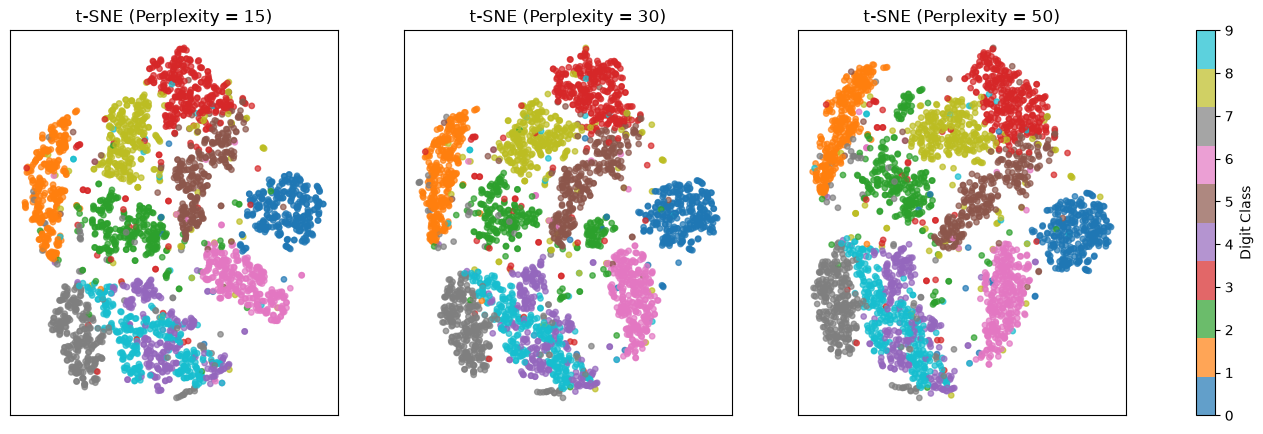

In [10]:
perplexities = [15, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, perp in enumerate(perplexities):
    tsne_model = TSNE(n_components=2, perplexity=perp, random_state=42)
    res_perp = tsne_model.fit_transform(X_pca_tsne_sample)
    sp = axes[i].scatter(res_perp[:, 0], res_perp[:, 1], c=y_tsne_sample, cmap='tab10', alpha=0.7, s=15)
    axes[i].set_title(f"t-SNE (Perplexity = {perp})")
    axes[i].set_xticks([])
    axes[i].set_yticks([])
plt.colorbar(sp, ax=axes.ravel().tolist(), label='Digit Class')
plt.show()

In [11]:
X_tr, X_te, y_tr, y_te = train_test_split(X_norm[:18000], y[:18000], test_size=3000, random_state=42, stratify=y[:18000])

t0 = time.time()
svm_orig = SVC(kernel='rbf')
svm_orig.fit(X_tr, y_tr)
train_time_orig = time.time() - t0

t0 = time.time()
acc_orig = svm_orig.score(X_te, y_te)
pred_time_orig = time.time() - t0

pca_model = PCA(n_components=50).fit(X_tr)
X_tr_pca = pca_model.transform(X_tr)
X_te_pca = pca_model.transform(X_te)

t0 = time.time()
svm_pca = SVC(kernel='rbf')
svm_pca.fit(X_tr_pca, y_tr)
train_time_pca = time.time() - t0

t0 = time.time()
acc_pca = svm_pca.score(X_te_pca, y_te)
pred_time_pca = time.time() - t0

   Representation  Accuracy  Training Time (s)  Prediction Time (s)
  Original (784D)     0.963          25.570115             9.071969
PCA-Reduced (50D)     0.972           1.761916             0.948846


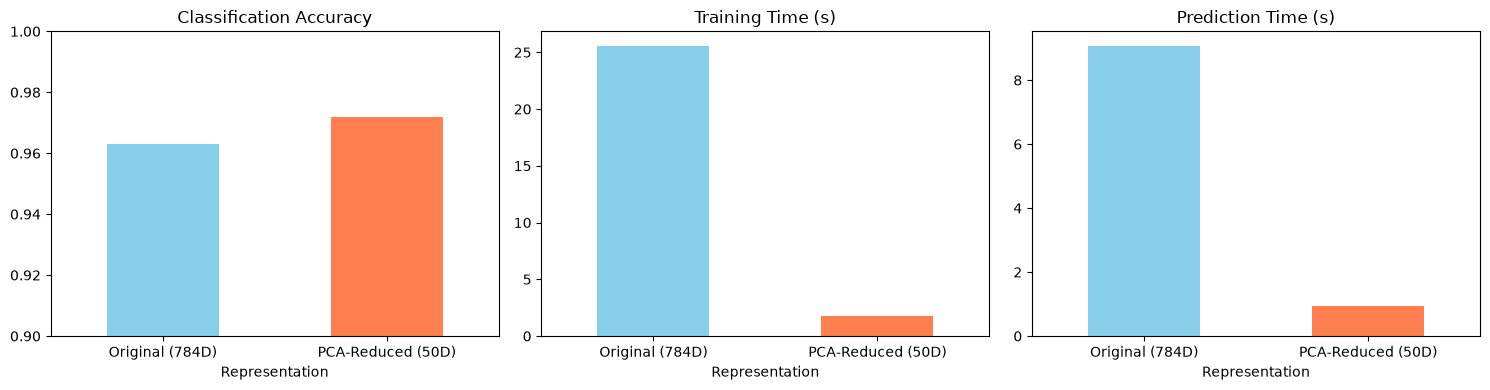

In [12]:
results_df = pd.DataFrame({
    'Representation': ['Original (784D)', 'PCA-Reduced (50D)'],
    'Accuracy': [acc_orig, acc_pca],
    'Training Time (s)': [train_time_orig, train_time_pca],
    'Prediction Time (s)': [pred_time_orig, pred_time_pca]
})
print(results_df.to_string(index=False))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
results_df.plot(x='Representation', y='Accuracy', kind='bar', ax=ax1, color=['skyblue', 'coral'], legend=False)
ax1.set_title('Classification Accuracy')
ax1.set_ylim(0.9, 1.0)
ax1.tick_params(axis='x', rotation=0)

results_df.plot(x='Representation', y='Training Time (s)', kind='bar', ax=ax2, color=['skyblue', 'coral'], legend=False)
ax2.set_title('Training Time (s)')
ax2.tick_params(axis='x', rotation=0)

results_df.plot(x='Representation', y='Prediction Time (s)', kind='bar', ax=ax3, color=['skyblue', 'coral'], legend=False)
ax3.set_title('Prediction Time (s)')
ax3.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()